# 04 — Feature Importance and Ablation Analysis

This notebook evaluates whether added feature groups actually improve validation performance.

It avoids recursive feature elimination on randomly split time-series data. Instead, it compares logically defined feature sets using the same chronological validation period.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)

def find_project_root() -> Path:
    candidates = [Path.cwd(), Path.cwd().parent]
    for candidate in candidates:
        if (candidate / "Data").exists() or (candidate / "data").exists():
            return candidate.resolve()
    return Path.cwd().resolve()

PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "Data"
OUTPUT_DIR = PROJECT_ROOT / "Outputs"
FIGURE_DIR = OUTPUT_DIR / "Figures"
MODEL_DIR = OUTPUT_DIR / "Models"

for directory in (DATA_DIR, FIGURE_DIR, MODEL_DIR):
    directory.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")

Project root: /mnt/WorkSpace/Repos/dublin-bikes-fix


In [2]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBRegressor

In [3]:
FEATURE_PATH = DATA_DIR / "dataset_forecasting_features.csv"
if not FEATURE_PATH.exists():
    raise FileNotFoundError("Run 03_forecasting_model.ipynb first.")

df = pd.read_csv(FEATURE_PATH, parse_dates=["TIME"])
df = df.sort_values("TIME").reset_index(drop=True)

unique_times = np.array(sorted(df["TIME"].unique()))
train_cutoff = unique_times[int(len(unique_times) * 0.70)]
validation_cutoff = unique_times[int(len(unique_times) * 0.85)]

train_df = df[df["TIME"] < train_cutoff].copy()
validation_df = df[
    (df["TIME"] >= train_cutoff)
    & (df["TIME"] < validation_cutoff)
].copy()

target = "TARGET_AVAILABLE_BIKES"

## Define feature groups

In [4]:
feature_sets = {
    "calendar_and_station": [
        "BIKE STANDS", "LATITUDE", "LONGITUDE",
        "HOUR_SIN", "HOUR_COS", "DOW_SIN", "DOW_COS",
        "IS_WEEKEND", "STATION ID", "STATUS",
    ],
    "plus_recent_lags": [
        "BIKE STANDS", "LATITUDE", "LONGITUDE",
        "HOUR_SIN", "HOUR_COS", "DOW_SIN", "DOW_COS",
        "IS_WEEKEND", "STATION ID", "STATUS",
        "AVAILABLE_BIKES_LAG_1", "AVAILABLE_BIKES_LAG_2",
        "AVAILABLE_BIKES_LAG_4", "AVAILABLE_BIKES_LAG_8",
    ],
    "plus_rolling_features": [
        "BIKE STANDS", "LATITUDE", "LONGITUDE",
        "HOUR_SIN", "HOUR_COS", "DOW_SIN", "DOW_COS",
        "IS_WEEKEND", "STATION ID", "STATUS",
        "AVAILABLE_BIKES_LAG_1", "AVAILABLE_BIKES_LAG_2",
        "AVAILABLE_BIKES_LAG_4", "AVAILABLE_BIKES_LAG_8",
        "ROLLING_MEAN_4", "ROLLING_STD_4", "ROLLING_MEAN_8",
        "MINUTES_SINCE_PREVIOUS",
    ],
}

In [5]:
def build_pipeline(features):
    categorical = [c for c in features if c in {"STATION ID", "STATUS"}]
    numeric = [c for c in features if c not in categorical]

    preprocessor = ColumnTransformer([
        (
            "numeric",
            Pipeline([("imputer", SimpleImputer(strategy="median"))]),
            numeric,
        ),
        (
            "categorical",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(handle_unknown="ignore")),
            ]),
            categorical,
        ),
    ])

    estimator = XGBRegressor(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=6,
        min_child_weight=3,
        subsample=0.85,
        colsample_bytree=0.85,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1,
    )

    return Pipeline([
        ("preprocessor", preprocessor),
        ("model", estimator),
    ])

## Run ablation experiments

In [6]:
experiment_results = []
trained_pipelines = {}

for name, features in feature_sets.items():
    experiment_df_train = train_df.dropna(subset=features + [target])
    experiment_df_validation = validation_df.dropna(subset=features + [target])

    pipeline = build_pipeline(features)
    pipeline.fit(
        experiment_df_train[features],
        experiment_df_train[target],
    )

    predictions = pipeline.predict(experiment_df_validation[features])
    predictions = np.clip(
        predictions,
        0,
        experiment_df_validation["BIKE STANDS"].to_numpy(),
    )

    experiment_results.append({
        "feature_set": name,
        "feature_count": len(features),
        "MAE": mean_absolute_error(
            experiment_df_validation[target],
            predictions,
        ),
        "RMSE": mean_squared_error(
            experiment_df_validation[target],
            predictions,
        ) ** 0.5,
        "R2": r2_score(
            experiment_df_validation[target],
            predictions,
        ),
    })
    trained_pipelines[name] = pipeline

result_df = pd.DataFrame(experiment_results).sort_values("MAE")
display(result_df)

,feature_set,feature_count,MAE,RMSE,R2
1,plus_recent_lags,14,1.575530,2.614131,0.900812
2,plus_rolling_features,18,1.575549,2.616854,0.900605
0,calendar_and_station,10,5.028581,6.370621,0.410926


## Plot ablation results

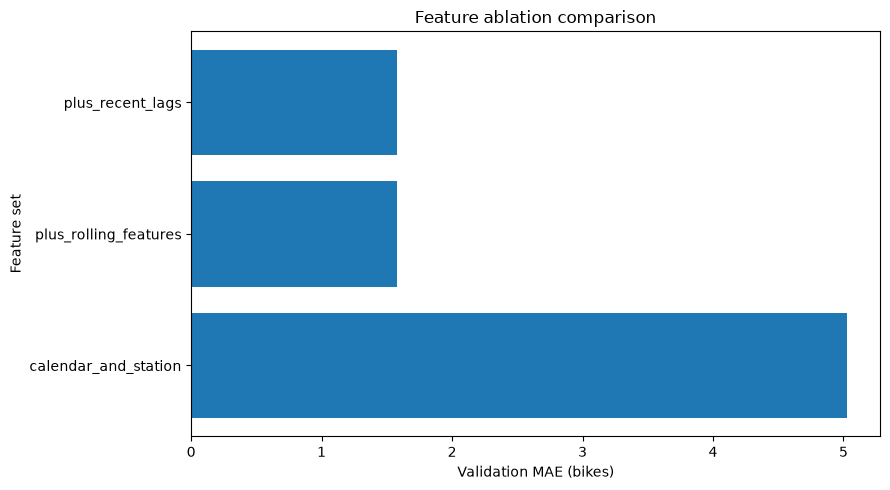

In [7]:
plot_df = result_df.sort_values("MAE", ascending=False)

plt.figure(figsize=(9, 5))
plt.barh(plot_df["feature_set"], plot_df["MAE"])
plt.xlabel("Validation MAE (bikes)")
plt.ylabel("Feature set")
plt.title("Feature ablation comparison")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "feature_ablation_mae.png", dpi=150)
plt.show()

## XGBoost feature importance

,feature,importance
8,numeric__AVAILABLE_BIKES_LAG_1,0.446827
9,numeric__AVAILABLE_BIKES_LAG_2,0.174165
0,numeric__BIKE STANDS,0.014702
36,categorical__STATION ID_28,0.012220
118,categorical__STATION ID_114,0.009856
41,categorical__STATION ID_33,0.009601
1,numeric__LATITUDE,0.007991
40,categorical__STATION ID_32,0.007459
2,numeric__LONGITUDE,0.007339
85,categorical__STATION ID_80,0.007068


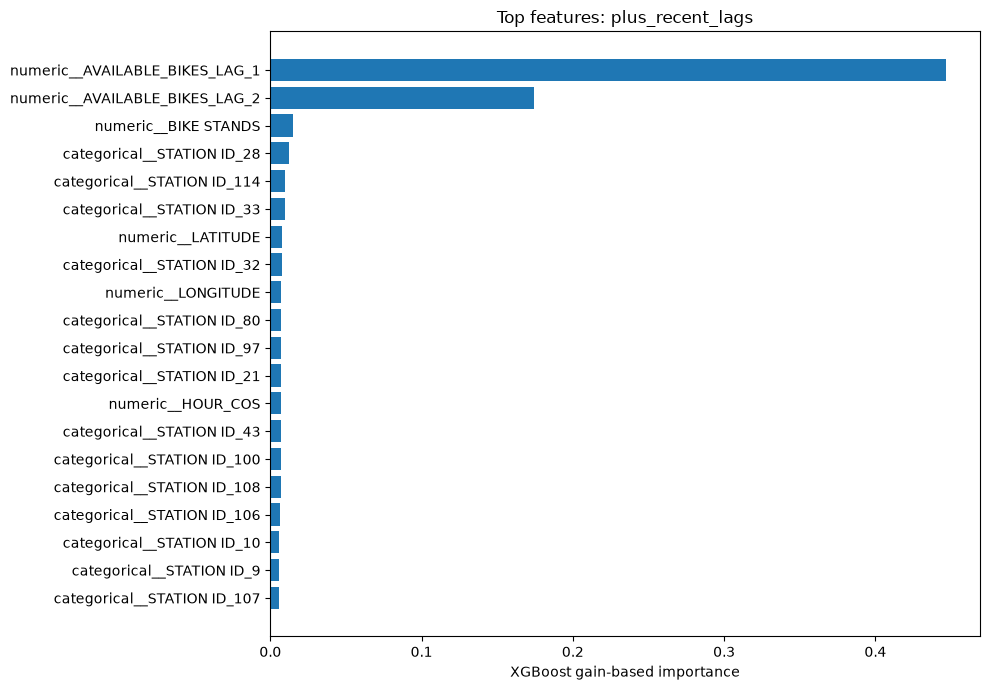

In [8]:
best_name = result_df.iloc[0]["feature_set"]
best_features = feature_sets[best_name]
best_pipeline = trained_pipelines[best_name]

transformed_names = best_pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()
importance = best_pipeline.named_steps[
    "model"
].feature_importances_

importance_df = (
    pd.DataFrame({
        "feature": transformed_names,
        "importance": importance,
    })
    .sort_values("importance", ascending=False)
)

display(importance_df.head(20))

plt.figure(figsize=(10, 7))
top = importance_df.head(20).sort_values("importance")
plt.barh(top["feature"], top["importance"])
plt.xlabel("XGBoost gain-based importance")
plt.title(f"Top features: {best_name}")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "xgboost_feature_importance.png", dpi=150)
plt.show()

## Interpretation guidance

Feature importance does not prove causality. Use the ablation table as the primary evidence for whether a feature group improves forecasting. For a more rigorous future version, add SHAP values and evaluate performance separately by station, hour, and forecast horizon.